# Фінальний проєкт: Pet Adoption Prediction (PetFinder.my)
## Прогноз швидкості адопції за фото та описом. 
Метрика: Quadratic Weighted Kappa

**Підхід:**
1. Заморожені енкодери: **SigLIP-base** (фото + текст) і **CLIP ViT-L/14** (фото). Для кожної тварини усереднюються ембединги всіх її фото.
2. **kNN-ознаки за мітками схожих оголошень** (за ембедингами фото й тексту). Рахуються строго всередині фолда без витоку міток.
3. Моделі першого рівня: Ridge, SVR (на ембедингах), LightGBM regression, LightGBM multiclass, CatBoost (на PCA-ембедингах + kNN-ознаках).
4. Ансамбль через NNLS-ваги та пороги, що максимізують QWK.
5. Фінальні моделі перенавчаються на всьому train.
6. Optuna використовується для LightGBM. AutoML-бібліотеки не використовуються.

## Крок 1. Імпорти, конфігурація, відтворюваність

In [4]:
import os, gc, re, random, warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.optimize import minimize, nnls
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, mean_squared_error
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------- Конфігурація ----------------
SEED = 42
N_SPLITS = 5
PCA_DIM = 128          # розмірність PCA-ембедингів для бустингів
OPT_TRIALS = 15        # кількість trial-ів Optuna
LGB_SEEDS = [42, 43, 44]
RUN_ABLATION = True    # внесок kNN-ознак
IMG_ENCODERS = {       # HuggingFace
    "siglip": "google/siglip-base-patch16-224",
    "clip":   "openai/clip-vit-large-patch14",
}

def seed_everything(seed=SEED):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
seed_everything()

## Крок 2. Завантаження даних

In [5]:
CANDIDATE_DIRS = [
    "/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10",
    "/kaggle/input/deep-learning-for-computer-vision-and-nlp-2026-10",
    "./data",
]
COMP_DIR = next((d for d in CANDIDATE_DIRS if os.path.exists(os.path.join(d, "train.csv"))), None)
assert COMP_DIR is not None, "Не знайдено train.csv. Вкажіть шлях у CANDIDATE_DIRS."

def find_img_dir(split):
    for p in [os.path.join(COMP_DIR, "images", "images", split), os.path.join(COMP_DIR, "images", split)]:
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(f"Не знайдено папку з фото для {split}")

TRAIN_IMG_DIR, TEST_IMG_DIR = find_img_dir("train"), find_img_dir("test")
CACHE_DIR = "/kaggle/working/cache" if COMP_DIR.startswith("/kaggle") else "./cache"
OUT_DIR = "/kaggle/working" if COMP_DIR.startswith("/kaggle") else "."
os.makedirs(CACHE_DIR, exist_ok=True)

df_train = pd.read_csv(os.path.join(COMP_DIR, "train.csv"))
df_test = pd.read_csv(os.path.join(COMP_DIR, "test.csv"))
df_sub = pd.read_csv(os.path.join(COMP_DIR, "sample_submission.csv"))
print("train:", df_train.shape, "| test:", df_test.shape, "| sample_submission:", df_sub.shape)

# Мінімальне очищення тексту: прибираємо HTML-теги, посилання, зайві пробіли
def clean_text(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else "No description"

n_na_tr, n_na_te = df_train["Description"].isna().sum(), df_test["Description"].isna().sum()
df_train["Description"] = df_train["Description"].map(clean_text)
df_test["Description"] = df_test["Description"].map(clean_text)
print(f"Пропусків в описах: train={n_na_tr}, test={n_na_te}")

def pet_image_map(img_dir):
    m = defaultdict(list)
    for fname in sorted(os.listdir(img_dir)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            m[fname.split("-")[0].split(".")[0]].append(fname)
    return m

train_map, test_map = pet_image_map(TRAIN_IMG_DIR), pet_image_map(TEST_IMG_DIR)
df_train["photo_count"] = df_train["PetID"].map(lambda p: len(train_map.get(p, [])))
df_test["photo_count"] = df_test["PetID"].map(lambda p: len(test_map.get(p, [])))
y = df_train["AdoptionSpeed"].values.astype(int)
display(df_train.head(3))

train: (6431, 3) | test: (1891, 2) | sample_submission: (4, 2)
Пропусків в описах: train=5, test=1


,PetID,Description,AdoptionSpeed,photo_count
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2,11
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2,1


## Крок 3. EDA

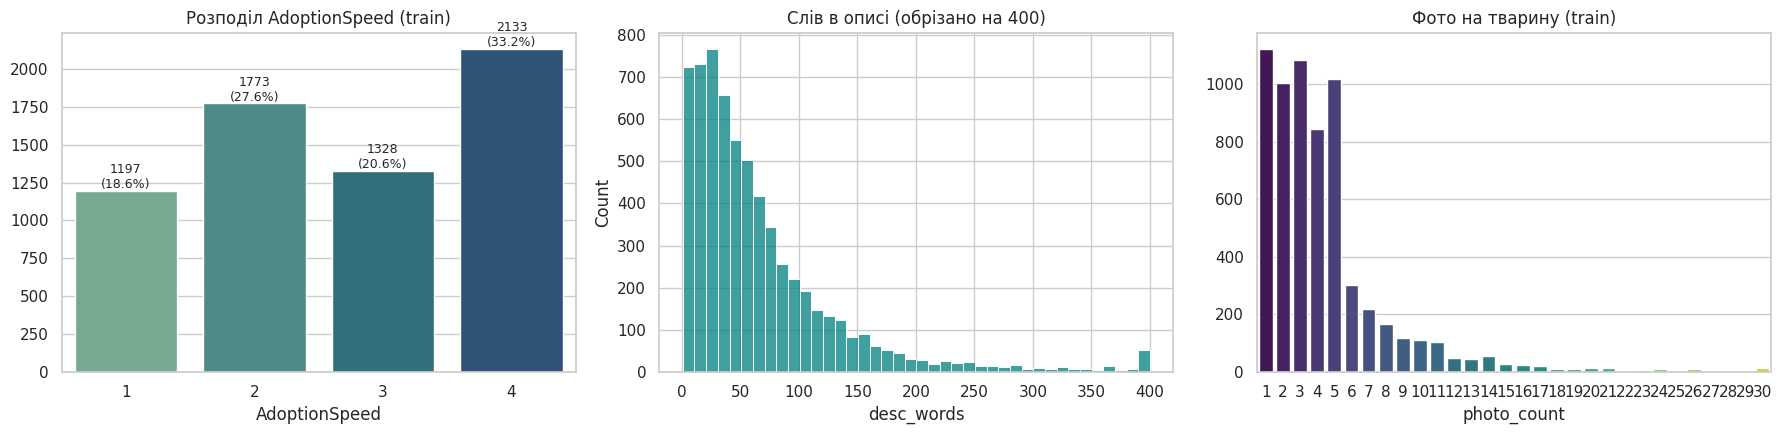

Тварин без фото: train=0, test=4
Середня к-сть фото: train=4.43, test=4.95
Частка оголошень із неунікальним описом у train: 6.6%
Серед груп однакових описів 68.1% мають одну й ту саму мітку -> дублікати не видаляємо, мітки схожих оголошень використаємо як ознаки


In [6]:
df_train["desc_words"] = df_train["Description"].str.split().str.len()
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
cnt = df_train["AdoptionSpeed"].value_counts().sort_index()
sns.barplot(x=cnt.index, y=cnt.values, ax=ax[0], palette="crest")
for i, (k, v) in enumerate(cnt.items()):
    ax[0].text(i, v + 15, f"{v}\n({v/len(df_train)*100:.1f}%)", ha="center", fontsize=9)
ax[0].set_title("Розподіл AdoptionSpeed (train)")
sns.histplot(df_train["desc_words"].clip(upper=400), bins=40, ax=ax[1], color="teal")
ax[1].set_title("Слів в описі (обрізано на 400)")
pc = df_train["photo_count"].value_counts().sort_index()
sns.barplot(x=pc.index, y=pc.values, ax=ax[2], palette="viridis")
ax[2].set_title("Фото на тварину (train)")
plt.tight_layout(); plt.show()

print(f"Тварин без фото: train={(df_train.photo_count==0).sum()}, test={(df_test.photo_count==0).sum()}")
print(f"Середня к-сть фото: train={df_train.photo_count.mean():.2f}, test={df_test.photo_count.mean():.2f}")
dup_share = df_train.duplicated("Description", keep=False).mean()
print(f"Частка оголошень із неунікальним описом у train: {dup_share:.1%}")
g = df_train[df_train.duplicated("Description", keep=False)].groupby("Description")["AdoptionSpeed"].nunique()
print(f"Серед груп однакових описів {np.mean(g==1):.1%} мають одну й ту саму мітку -> дублікати не видаляємо, "
      f"мітки схожих оголошень використаємо як ознаки")

**Висновки EDA:** найбільший клас - 4, найменший - 1, тож порогова оптимізація під QWK доречна. Є тварини без фото (у test), для них ембединг буде нульовим вектором. Однакові або дуже схожі оголошення часто мають однакову мітку. Тому дублікати не видаляємо, а будуємо ознаки на мітках найближчих сусідів.

## Крок 4. Stratified K-Fold

In [7]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_arr = np.full(len(df_train), -1)
for f, (_, va) in enumerate(skf.split(df_train, y)):
    fold_arr[va] = f
print(pd.crosstab(fold_arr, y, normalize="index").round(3))

col_0      1      2      3      4
row_0                            
0      0.186  0.276  0.207  0.332
1      0.187  0.276  0.206  0.331
2      0.187  0.276  0.206  0.331
3      0.186  0.275  0.207  0.332
4      0.186  0.275  0.207  0.332


## Крок 5. Ембединги (SigLIP-base для фото й тексту, CLIP ViT-L/14 для фото)
Усі фото кожної тварини -> L2-нормалізація -> усереднення -> повторна нормалізація. Результати кешуються у `.npy`; повторний запуск пропускає цей крок.

In [8]:
EMB_KEYS = ["siglip_img", "siglip_txt", "clip_img"]
def cpath(k, split): return os.path.join(CACHE_DIR, f"{k}_{split}.npy")
need_extract = any(not os.path.exists(cpath(k, s)) for k in EMB_KEYS for s in ("train", "test"))
print("Потрібне вилучення ембедингів:", need_extract)

if need_extract:
    import torch
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoProcessor, AutoModel

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = torch.float16 if device.type == "cuda" else torch.float32
    print("Пристрій:", device)

    def as_tensor(out):
        # сумісність версій transformers: тензор або ModelOutput із pooler_output
        if isinstance(out, torch.Tensor):
            return out
        if getattr(out, "pooler_output", None) is not None:
            return out.pooler_output
        return out[0]

    class PetImages(Dataset):
        def __init__(self, items, image_processor):
            self.items, self.proc = items, image_processor
        def __len__(self): return len(self.items)
        def __getitem__(self, i):
            pet_idx, path = self.items[i]
            try:
                img = Image.open(path).convert("RGB")
                return self.proc(images=img, return_tensors="pt")["pixel_values"][0], pet_idx
            except Exception:
                return None

    def collate(batch):
        batch = [b for b in batch if b is not None]
        if not batch:
            return None
        return torch.stack([b[0] for b in batch]), torch.tensor([b[1] for b in batch])

    @torch.no_grad()
    def extract_image_embeddings(model, processor, df, img_map, img_dir, batch_size=64):
        items = [(i, os.path.join(img_dir, fn)) for i, pid in enumerate(df["PetID"]) for fn in img_map.get(pid, [])]
        dl = DataLoader(PetImages(items, processor.image_processor), batch_size=batch_size,
                        num_workers=2, collate_fn=collate)
        sums, counts = None, np.zeros(len(df))
        for batch in tqdm(dl, desc="фото"):
            if batch is None:
                continue
            pix, idx = batch
            feats = as_tensor(model.get_image_features(pixel_values=pix.to(device, dtype=dtype))).float()
            feats = F.normalize(feats, dim=-1).cpu().numpy()
            if sums is None:
                sums = np.zeros((len(df), feats.shape[1]), np.float32)
            np.add.at(sums, idx.numpy(), feats)
            np.add.at(counts, idx.numpy(), 1)
        emb = np.zeros_like(sums)
        ok = counts > 0
        emb[ok] = sums[ok] / counts[ok, None]
        emb[ok] /= np.linalg.norm(emb[ok], axis=1, keepdims=True) + 1e-9
        return emb

    @torch.no_grad()
    def extract_text_embeddings(model, processor, texts, max_length=64, batch_size=128):
        out_all = []
        for i in tqdm(range(0, len(texts), batch_size), desc="тексти"):
            inp = processor(text=texts[i:i + batch_size], padding="max_length", max_length=max_length,
                            truncation=True, return_tensors="pt").to(device)
            feats = as_tensor(model.get_text_features(**inp)).float()
            out_all.append(F.normalize(feats, dim=-1).cpu().numpy())
        return np.vstack(out_all)

    for name, ckpt in IMG_ENCODERS.items():
        print(f"\n=== {name}: {ckpt} ===")
        processor = AutoProcessor.from_pretrained(ckpt)
        model = AutoModel.from_pretrained(ckpt).to(device).eval()
        if device.type == "cuda":
            model = model.half()
        for split, df, mp, d in [("train", df_train, train_map, TRAIN_IMG_DIR), ("test", df_test, test_map, TEST_IMG_DIR)]:
            if not os.path.exists(cpath(f"{name}_img", split)):
                np.save(cpath(f"{name}_img", split), extract_image_embeddings(model, processor, df, mp, d))
            if name == "siglip" and not os.path.exists(cpath("siglip_txt", split)):
                np.save(cpath("siglip_txt", split), extract_text_embeddings(model, processor, df["Description"].tolist()))
        del model, processor; gc.collect(); torch.cuda.empty_cache()

emb = {(k, s): np.load(cpath(k, s)).astype(np.float32) for k in EMB_KEYS for s in ("train", "test")}
for key, v in emb.items():
    print(key, v.shape)

Потрібне вилучення ембедингів: True


Пристрій: cuda

=== siglip: google/siglip-base-patch16-224 ===


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


фото:   0%|          | 0/445 [00:00<?, ?it/s]

фото:   0%|          | 0/147 [00:00<?, ?it/s]

('siglip_img', 'train') (6431, 768)
('siglip_img', 'test') (1891, 768)
('siglip_txt', 'train') (6431, 768)
('siglip_txt', 'test') (1891, 768)
('clip_img', 'train') (6431, 768)
('clip_img', 'test') (1891, 768)


## Крок 6. Простори ознак
* `E_img`: конкатенація нормалізованих image-ембедингів двох енкодерів, поділена на √2 (косинусна подібність дорівнює середньому косинусів). Використовується для пошуку схожих фото.
* `E_txt`: текстові ембединги. Використовуються для пошуку схожих описів (майже дублікатів).
* `X_emb`: повні ембединги (SigLIP img + SigLIP txt + CLIP img) для Ridge та SVR.
* `PCA`: стиснені ембединги для бустингів. PCA не використовує міток, тому підганяється на train+test без витоку цільової змінної.

In [9]:
def spaces(split):
    img = np.hstack([emb[("siglip_img", split)], emb[("clip_img", split)]]) / np.sqrt(2)
    txt = emb[("siglip_txt", split)]
    full = np.hstack([emb[("siglip_img", split)], emb[("siglip_txt", split)], emb[("clip_img", split)]])
    return img.astype(np.float32), txt, full

E_img_tr, E_txt_tr, X_emb_tr = spaces("train")
E_img_te, E_txt_te, X_emb_te = spaces("test")

pca = PCA(n_components=PCA_DIM, random_state=SEED).fit(np.vstack([X_emb_tr, X_emb_te]))
P_tr, P_te = pca.transform(X_emb_tr).astype(np.float32), pca.transform(X_emb_te).astype(np.float32)
print(f"PCA: {PCA_DIM} компонент, пояснена дисперсія = {pca.explained_variance_ratio_.sum():.1%}")

PCA: 128 компонент, пояснена дисперсія = 70.5%


## Крок 7. Метрика QWK, оптимізатор порогів, kNN-ознаки
**kNN-ознаки:** для кожного об'єкта беруться мітки найближчих сусідів лише з навчальної частини поточного фолда. Для самих навчальних рядків сусіди шукаються серед інших навчальних рядків, а для валідаційних рядків та test - серед усього навчального набору.

In [10]:
def qwk(y_true, y_pred):
    """Quadratic Weighted Kappa для класів 1..4 (збігається з sklearn cohen_kappa_score(weights='quadratic'))."""
    y_true, y_pred = np.asarray(y_true).astype(int), np.asarray(y_pred).astype(int)
    O = np.bincount((y_true - 1) * 4 + (y_pred - 1), minlength=16).reshape(4, 4).astype(float)
    E = np.outer(O.sum(1), O.sum(0)) / O.sum()
    i = np.arange(4)
    W = (i[:, None] - i[None, :]) ** 2 / 9.0
    return 1.0 - (W * O).sum() / (W * E).sum()

def apply_thr(x, thr):
    return np.searchsorted(np.sort(thr), x, side="right") + 1

class OptimizedRounder:
    """Пороги [t1,t2,t3] для перетворення неперервного прогнозу в клас 1..4 під максимізацію QWK.
    Nelder-Mead із кількох стартових точок (QWK кусково-стала, тому одного старту недостатньо)."""
    def fit(self, x, y):
        x, y = np.asarray(x, float), np.asarray(y)
        prior = np.cumsum(np.bincount(y, minlength=5)[1:]) / len(y)
        starts = [[1.5, 2.5, 3.5], list(np.quantile(x, prior[:3])), [1.7, 2.6, 3.0]]
        best = None
        for s in starts:
            r = minimize(lambda t: -qwk(y, apply_thr(x, t)), s, method="Nelder-Mead",
                         options={"xatol": 1e-3, "fatol": 1e-6, "maxiter": 400})
            if best is None or r.fun < best.fun:
                best = r
        self.thr_ = np.sort(best.x)
        return self
    def predict(self, x):
        return apply_thr(np.asarray(x, float), self.thr_)

def crossfit_qwk(oof, y, folds):
    """Чесна оцінка: пороги для кожного фолда підбираються на ІНШИХ фолдах."""
    pred = np.zeros(len(y), int)
    for f in np.unique(folds):
        tr, va = folds != f, folds == f
        pred[va] = OptimizedRounder().fit(oof[tr], y[tr]).predict(oof[va])
    return qwk(y, pred)

def knn_features(Q, R, yR, self_exclude, prefix, ks=(5, 20), T=0.1, dup=0.95):
    S = Q @ R.T
    if self_exclude:
        np.fill_diagonal(S, -1.0)
    K = max(max(ks), 10)
    idx = np.argpartition(-S, K - 1, axis=1)[:, :K]
    ss = np.take_along_axis(S, idx, 1)
    o = np.argsort(-ss, 1)
    idx, ss = np.take_along_axis(idx, o, 1), np.take_along_axis(ss, o, 1)
    lab = yR[idx].astype(float)
    F_ = {f"{prefix}_sim1": ss[:, 0], f"{prefix}_lab1": lab[:, 0]}
    for k in ks:
        w = np.exp((ss[:, :k] - ss[:, :1]) / T)
        F_[f"{prefix}_wlab{k}"] = (w * lab[:, :k]).sum(1) / w.sum(1)
        F_[f"{prefix}_msim{k}"] = ss[:, :k].mean(1)
    w = np.exp((ss[:, :10] - ss[:, :1]) / T)
    for c in range(1, 5):
        F_[f"{prefix}_p{c}"] = (w * (lab[:, :10] == c)).sum(1) / w.sum(1)
    F_[f"{prefix}_ndup"] = (ss > dup).sum(1)
    return np.column_stack(list(F_.values())).astype(np.float32), list(F_)

def knn_block(Qi, Qt, Ri, Rt, yR, self_exclude):
    A, na = knn_features(Qi, Ri, yR, self_exclude, "img")
    B, nb = knn_features(Qt, Rt, yR, self_exclude, "txt", ks=(5,), dup=0.97)
    return np.hstack([A, B]), na + nb

# швидка перевірка, що kNN-ознака сама по собі інформативна (OOF, без витоку)
tmp = np.zeros(len(y))
for f in range(N_SPLITS):
    tr, va = np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]
    Kva, nm = knn_block(E_img_tr[va], E_txt_tr[va], E_img_tr[tr], E_txt_tr[tr], y[tr], False)
    tmp[va] = Kva[:, nm.index("img_wlab20")]
print(f"QWK лише за зваженою міткою 20 сусідів по фото: {crossfit_qwk(tmp, y, fold_arr):.4f}")

QWK лише за зваженою міткою 20 сусідів по фото: 0.5442


## Крок 8. Фолд-ознаки (PCA + kNN) для всіх моделей

In [11]:
FOLD = {}
for f in range(N_SPLITS):
    tr, va = np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]
    Ktr, knn_names = knn_block(E_img_tr[tr], E_txt_tr[tr], E_img_tr[tr], E_txt_tr[tr], y[tr], True)
    Kva, _ = knn_block(E_img_tr[va], E_txt_tr[va], E_img_tr[tr], E_txt_tr[tr], y[tr], False)
    FOLD[f] = dict(tr=tr, va=va, Xtab_tr=np.hstack([P_tr[tr], Ktr]), Xtab_te=np.hstack([P_tr[va], Kva]),
                   Xemb_tr=X_emb_tr[tr], Xemb_te=X_emb_tr[va], y_tr=y[tr])
TAB_NAMES = [f"pca_{i}" for i in range(PCA_DIM)] + knn_names
print("Табличних ознак:", len(TAB_NAMES), f"(PCA {PCA_DIM} + kNN {len(knn_names)})")

Табличних ознак: 148 (PCA 128 + kNN 20)


## Крок 9. Optuna для LightGBM (regression)
Цільова функція - **OOF RMSE** (гладка й стабільна; QWK із підбором порогів дуже шумний, тому як критерій пошуку він гірший). QWK повідомляється окремо. Кількість trial-ів фіксована, без `timeout`, щоб запуск відтворювався. Оптимальна кількість раундів береться як середнє `best_iteration` по фолдах і далі використовується фіксованою. У фінальному CV та у фінальному перенавчанні ранньої зупинки на валідації немає.

In [12]:
def lgb_params_from(trial):
    return {
        "objective": "regression", "metric": "rmse", "verbosity": -1, "num_threads": -1,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 48),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 50.0, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.8),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95), "subsample_freq": 1,
        "seed": SEED,
    }

def objective(trial):
    params = lgb_params_from(trial)
    oof, iters = np.zeros(len(y)), []
    for f in range(N_SPLITS):
        d = FOLD[f]
        dtr = lgb.Dataset(d["Xtab_tr"], d["y_tr"])
        dva = lgb.Dataset(d["Xtab_te"], y[d["va"]], reference=dtr)
        m = lgb.train(params, dtr, 800, valid_sets=[dva], callbacks=[lgb.early_stopping(40, verbose=False)])
        oof[d["va"]] = m.predict(d["Xtab_te"], num_iteration=m.best_iteration)
        iters.append(m.best_iteration)
    trial.set_user_attr("rounds", int(np.mean(iters)))
    return float(np.sqrt(np.mean((oof - y) ** 2)))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=OPT_TRIALS, show_progress_bar=True)

BEST_LGB = {**lgb_params_from(optuna.trial.FixedTrial(study.best_params)),}
LGB_ROUNDS = max(60, study.best_trial.user_attrs["rounds"])
print(f"Найкращий OOF RMSE: {study.best_value:.4f} | раундів: {LGB_ROUNDS}")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in study.best_params.items()})

  0%|          | 0/15 [00:00<?, ?it/s]

Найкращий OOF RMSE: 0.8890 | раундів: 250
{'learning_rate': 0.0305, 'num_leaves': 36, 'max_depth': 6, 'min_child_samples': 67, 'reg_alpha': 2.006, 'reg_lambda': 7.8828, 'colsample_bytree': 0.7891, 'subsample': 0.6168}


## Крок 10. Моделі першого рівня (5-fold OOF)

In [13]:
FULL_LGB_MODELS = []

RIDGE_ALPHA = 10.0  # значення за замовчуванням;

def m_ridge(c):
    return Ridge(alpha=RIDGE_ALPHA).fit(c["Xemb_tr"], c["y_tr"]).predict(c["Xemb_te"])

def m_svr(c):
    return SVR(C=1.0, epsilon=0.2).fit(c["Xemb_tr"], c["y_tr"]).predict(c["Xemb_te"])

def m_lgb_reg(c):
    preds = []
    for s in LGB_SEEDS:
        m = lgb.train({**BEST_LGB, "seed": s}, lgb.Dataset(c["Xtab_tr"], c["y_tr"]), LGB_ROUNDS)
        preds.append(m.predict(c["Xtab_te"]))
        if c.get("full"):
            FULL_LGB_MODELS.append(m)
    return np.mean(preds, axis=0)

def m_lgb_mc(c):
    p = {**BEST_LGB, "objective": "multiclass", "num_class": 4, "metric": "multi_logloss", "learning_rate": 0.05}
    preds = []
    for s in LGB_SEEDS:
        m = lgb.train({**p, "seed": s}, lgb.Dataset(c["Xtab_tr"], c["y_tr"] - 1), MC_ROUNDS)
        preds.append(m.predict(c["Xtab_te"]) @ np.array([1.0, 2.0, 3.0, 4.0]))
    return np.mean(preds, axis=0)

def m_cb(c):
    m = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=SEED, verbose=0, thread_count=-1)
    return m.fit(c["Xtab_tr"], c["y_tr"]).predict(c["Xtab_te"])

def run_cv(fn, name):
    oof = np.zeros(len(y))
    for f in range(N_SPLITS):
        d = FOLD[f]
        oof[d["va"]] = fn(d)
    rmse = np.sqrt(np.mean((oof - y) ** 2))
    print(f"{name:12s} OOF RMSE={rmse:.4f} | QWK (cross-fit пороги)={crossfit_qwk(oof, y, fold_arr):.4f}")
    return oof

# --- Ridge: вибір alpha по OOF RMSE
alphas = [1, 3, 10, 30, 100]
rm = []
for a in alphas:
    RIDGE_ALPHA = a
    o = np.zeros(len(y))
    for f in range(N_SPLITS):
        o[FOLD[f]["va"]] = m_ridge(FOLD[f])
    rm.append(np.sqrt(np.mean((o - y) ** 2)))
RIDGE_ALPHA = alphas[int(np.argmin(rm))]
print("Ridge alpha:", RIDGE_ALPHA, [round(r, 4) for r in rm])

# --- кількість раундів для multiclass (рання зупинка лише для вибору числа раундів)
p_mc = {**BEST_LGB, "objective": "multiclass", "num_class": 4, "metric": "multi_logloss", "learning_rate": 0.05}
its = []
for f in range(N_SPLITS):
    d = FOLD[f]
    dtr = lgb.Dataset(d["Xtab_tr"], d["y_tr"] - 1)
    dva = lgb.Dataset(d["Xtab_te"], y[d["va"]] - 1, reference=dtr)
    its.append(lgb.train(p_mc, dtr, 600, valid_sets=[dva], callbacks=[lgb.early_stopping(40, verbose=False)]).best_iteration)
MC_ROUNDS = max(60, int(np.mean(its)))
print("LightGBM multiclass раундів:", MC_ROUNDS)

OOF = {}
OOF["ridge"] = run_cv(m_ridge, "Ridge")
OOF["svr"] = run_cv(m_svr, "SVR")
OOF["lgb_reg"] = run_cv(m_lgb_reg, "LGB reg")
OOF["lgb_mc"] = run_cv(m_lgb_mc, "LGB multicls")
OOF["catboost"] = run_cv(m_cb, "CatBoost")

Ridge alpha: 3 [np.float64(0.8993), np.float64(0.8883), np.float64(0.8934), np.float64(0.9146), np.float64(0.9624)]
LightGBM multiclass раундів: 161
Ridge        OOF RMSE=0.8883 | QWK (cross-fit пороги)=0.5939
SVR          OOF RMSE=0.8896 | QWK (cross-fit пороги)=0.5969
LGB reg      OOF RMSE=0.8875 | QWK (cross-fit пороги)=0.5884
LGB multicls OOF RMSE=0.8851 | QWK (cross-fit пороги)=0.5822
CatBoost     OOF RMSE=0.8927 | QWK (cross-fit пороги)=0.5820


### Абляція: внесок kNN-ознак
LightGBM із тими самими параметрами лише на PCA-ембедингах проти PCA + kNN-ознаки.

In [14]:
if RUN_ABLATION:
    def m_lgb_noknn(c):
        c2 = dict(c, Xtab_tr=c["Xtab_tr"][:, :PCA_DIM], Xtab_te=c["Xtab_te"][:, :PCA_DIM])
        return m_lgb_reg(c2)
    o_no = run_cv(m_lgb_noknn, "LGB без kNN")
    print(f"Приріст QWK від kNN-ознак: {crossfit_qwk(OOF['lgb_reg'], y, fold_arr) - crossfit_qwk(o_no, y, fold_arr):+.4f}")

LGB без kNN  OOF RMSE=0.8977 | QWK (cross-fit пороги)=0.5784
Приріст QWK від kNN-ознак: +0.0100


## Крок 11. Ансамбль: NNLS-ваги + пороги
Ваги знаходяться через `scipy.optimize.nnls`. Пороги підбираються на змішаному OOF.

Ваги ансамблю: {'ridge': np.float64(0.05), 'svr': np.float64(0.43), 'lgb_reg': np.float64(0.0), 'lgb_mc': np.float64(0.457), 'catboost': np.float64(0.063)}
Ensemble OOF RMSE: 0.8717
Ensemble QWK (cross-fit, чесна оцінка):             0.6073
Ensemble QWK (пороги на тому ж OOF, оптимістично):  0.6116
Пороги: [1.935 2.667 3.242]


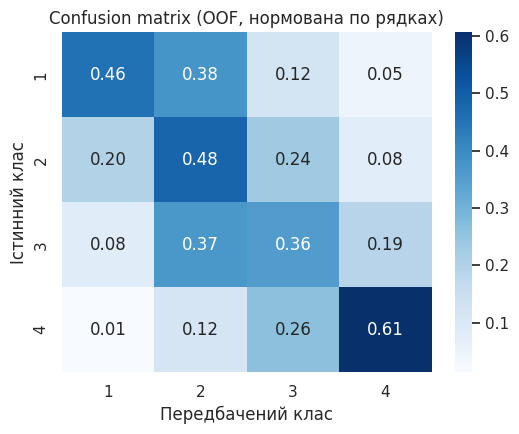

In [15]:
names = list(OOF)
P_oof = np.column_stack([OOF[n] for n in names])
w_raw, _ = nnls(P_oof, y.astype(float))
W = w_raw / w_raw.sum()
print("Ваги ансамблю:", {n: round(w, 3) for n, w in zip(names, W)})

blend_oof = P_oof @ W
final_rounder = OptimizedRounder().fit(blend_oof, y)
oof_labels = final_rounder.predict(blend_oof)

print(f"Ensemble OOF RMSE: {np.sqrt(np.mean((blend_oof - y) ** 2)):.4f}")
print(f"Ensemble QWK (cross-fit, чесна оцінка):             {crossfit_qwk(blend_oof, y, fold_arr):.4f}")
print(f"Ensemble QWK (пороги на тому ж OOF, оптимістично):  {qwk(y, oof_labels):.4f}")
print("Пороги:", np.round(final_rounder.thr_, 3))

cm = confusion_matrix(y, oof_labels, labels=[1, 2, 3, 4])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.xlabel("Передбачений клас"); plt.ylabel("Істинний клас"); plt.title("Confusion matrix (OOF, нормована по рядках)")
plt.tight_layout(); plt.show()

## Крок 12. Фінальне перенавчання на всьому train
Усі моделі першого рівня перенавчаються на 100% тренувальних даних з тими самими гіперпараметрами та числом раундів, ваги та пороги беруться з OOF. kNN-ознаки для train рахуються leave-one-out по всьому train, для test - по всьому train.

In [16]:
K_full_tr, _ = knn_block(E_img_tr, E_txt_tr, E_img_tr, E_txt_tr, y, True)
K_full_te, _ = knn_block(E_img_te, E_txt_te, E_img_tr, E_txt_tr, y, False)
FULL = dict(Xtab_tr=np.hstack([P_tr, K_full_tr]), Xtab_te=np.hstack([P_te, K_full_te]),
            Xemb_tr=X_emb_tr, Xemb_te=X_emb_te, y_tr=y, full=True)

fns = {"ridge": m_ridge, "svr": m_svr, "lgb_reg": m_lgb_reg, "lgb_mc": m_lgb_mc, "catboost": m_cb}
TEST_PRED = {}
for n in names:
    TEST_PRED[n] = fns[n](FULL)
    print(f"{n:10s} готово | середній прогноз test={TEST_PRED[n].mean():.3f} (train y={y.mean():.3f})")

blend_test = np.column_stack([TEST_PRED[n] for n in names]) @ W
test_labels = final_rounder.predict(blend_test)

print("\nКореляції прогнозів моделей на test:")
display(pd.DataFrame(TEST_PRED).corr().round(3))
comp = pd.DataFrame({"train_prior": pd.Series(y).value_counts(normalize=True).sort_index(),
                     "OOF_pred": pd.Series(oof_labels).value_counts(normalize=True).sort_index(),
                     "test_pred": pd.Series(test_labels).value_counts(normalize=True).sort_index()}).round(3)
print("Розподіл класів (перевірка узгодженості OOF та test):")
display(comp)

ridge      готово | середній прогноз test=2.717 (train y=2.684)
svr        готово | середній прогноз test=2.760 (train y=2.684)
lgb_reg    готово | середній прогноз test=2.725 (train y=2.684)
lgb_mc     готово | середній прогноз test=2.739 (train y=2.684)
catboost   готово | середній прогноз test=2.728 (train y=2.684)

Кореляції прогнозів моделей на test:


,ridge,svr,lgb_reg,lgb_mc,catboost
ridge,1.000,0.988,0.921,0.913,0.912
svr,0.988,1.000,0.926,0.922,0.917
lgb_reg,0.921,0.926,1.000,0.987,0.983
lgb_mc,0.913,0.922,0.987,1.000,0.976
catboost,0.912,0.917,0.983,0.976,1.000


Розподіл класів (перевірка узгодженості OOF та test):


,train_prior,OOF_pred,test_pred
1,0.186,0.162,0.171
2,0.276,0.318,0.300
3,0.206,0.249,0.211
4,0.332,0.271,0.318


## Крок 13. Інтерпретація моделі

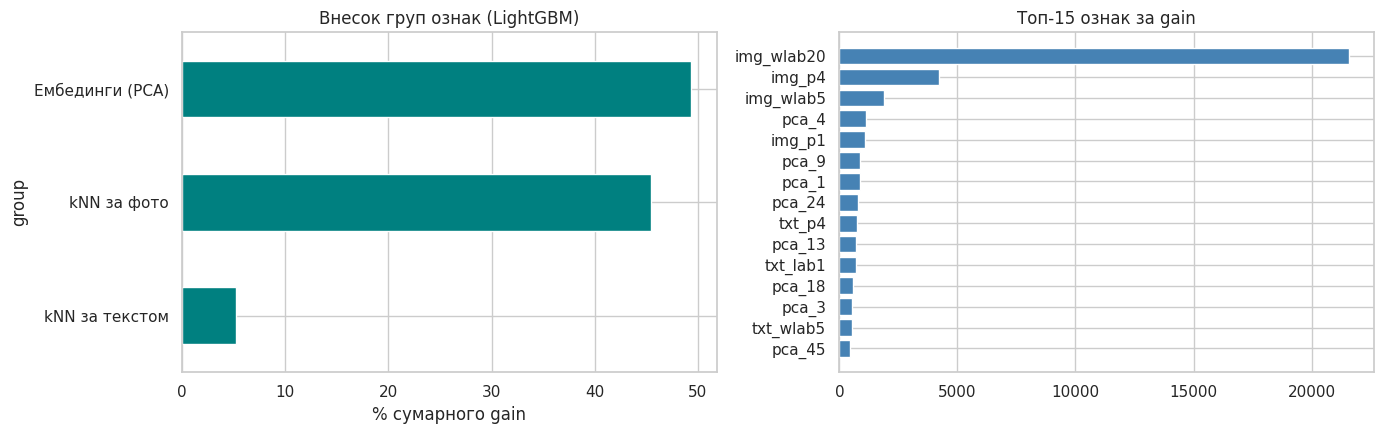

In [17]:
imp = np.mean([m.feature_importance("gain") for m in FULL_LGB_MODELS], axis=0)
imp_df = pd.DataFrame({"feature": TAB_NAMES, "gain": imp})
imp_df["group"] = np.where(imp_df.feature.str.startswith("pca_"), "Ембединги (PCA)",
                   np.where(imp_df.feature.str.startswith("img_"), "kNN за фото", "kNN за текстом"))
grp = imp_df.groupby("group")["gain"].sum().sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
(grp / grp.sum() * 100).plot.barh(ax=ax[0], color="teal"); ax[0].set_xlabel("% сумарного gain"); ax[0].set_title("Внесок груп ознак (LightGBM)")
top = imp_df.sort_values("gain").tail(15)
ax[1].barh(top.feature, top.gain, color="steelblue"); ax[1].set_title("Топ-15 ознак за gain")
plt.tight_layout(); plt.show()

## Крок 14. Формування та перевірка submission

In [18]:
submission = pd.DataFrame({"PetID": df_test["PetID"].values, "AdoptionSpeed": test_labels.astype(int)})
sub_path = os.path.join(OUT_DIR, "submission.csv")
submission.to_csv(sub_path, index=False)

# --- перевірки формату змагання
chk = pd.read_csv(sub_path)
assert list(chk.columns) == ["PetID", "AdoptionSpeed"] == list(df_sub.columns), "невірні колонки"
assert len(chk) == len(df_test) and chk["PetID"].is_unique, "невірна кількість або дублі PetID"
assert set(chk["PetID"]) == set(df_test["PetID"]), "PetID не збігаються з test.csv"
assert chk["AdoptionSpeed"].isin([1, 2, 3, 4]).all(), "AdoptionSpeed поза 1..4"
print(f"OK: {sub_path} | рядків: {len(chk)}")
display(chk.head())
print(chk["AdoptionSpeed"].value_counts().sort_index())

OK: /kaggle/working/submission.csv | рядків: 1891


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


AdoptionSpeed
1    323
2    568
3    399
4    601
Name: count, dtype: int64


## Підсумкові висновки

### 1. Задача та підхід
Метою роботи було прогнозування швидкості адопції тварин (класи 1–4) за фотографіями та текстовими описами з оптимізацією метрики **Quadratic Weighted Kappa (QWK)**.
* **Дані:** 6431 об'єкт у навчальній вибірці та 1891 у тестовій (4 тварини в тесті не мають фотографій).
* **Ембединги:** використано комбінацію заморожених моделей **SigLIP-base** (фото та текст) і **CLIP ViT-L/14** (фото). Для кожної тварини вектори всіх наявних зображень L2-нормалізувалися та усереднювалися.
* **Моделі:** побудовано п'ять моделей першого рівня — Ridge та SVR (на повних ембедингах), LightGBM regression, LightGBM multiclass та CatBoost (на 128 PCA-компонентах та kNN-ознаках).
* **Ансамблювання:** ваги визначено за допомогою невід'ємного методу найменших квадратів (**NNLS**), а неперервний прогноз переведено у дискретні класи оптимізатором порогів Nelder-Mead. Фінальні моделі перенавчено на 100% тренувальних даних відповідно до вимог пайплайну.

---

### 2. Результати валідації та тестування

Оцінка надійності проведена за допомогою 5-fold Stratified CV. Для уникнення оптимістичного зміщення пороги для кожного фолда підбиралися виключно на інших фолдах (**cross-fit**).

| Модель / Етап | Простір ознак | OOF RMSE | QWK (cross-fit) | QWK (оптимістичний) | Kaggle Public LB |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Ridge baseline** | SigLIP | — | — | 0.5503 | 0.7453 |
| **LightGBM baseline** | SigLIP | — | — | 0.5750 | 0.7713 |
| **CatBoost baseline** | SigLIP | — | — | 0.5720 | 0.7726 |
| **Ridge ($\alpha=3$)** | SigLIP + CLIP (2304) | 0.8883 | 0.5939 | — | — |
| **SVR ($C=1.0$)** | SigLIP + CLIP (2304) | 0.8896 | 0.5969 | — | — |
| **LightGBM regression** | PCA (128) + kNN (20) | 0.8875 | 0.5884 | — | — |
| **LightGBM multiclass** | PCA (128) + kNN (20) | **0.8851** | 0.5822 | — | — |
| **CatBoost** | PCA (128) + kNN (20) | 0.8927 | 0.5820 | — | — |
| **Попередній ансамбль** | SigLIP | — | — | 0.5916 | 0.7900 |
| **Фінальний ансамбль** | **Всі 5 моделей** | **0.8717** | **0.6073** | **0.6116** | **0.8003** |

* Ансамбль досяг точності **0.8003 на Public LB** (попередній максимум — 0.7900). Всі попередні дані на кегл створені на основі іншого варіанту коду (version 1 на git https://github.com/svetazo060510/deepLearning_finalproject_SvitlanaStremedlovska, де я використовувала інший підхід у експериментах.
* Різниця між чесною cross-fit оцінкою (0.6073) та оптимістичною (0.6116) становить лише **0.0043**, що підтверджує стійкість знайдених порогів `[1.935, 2.667, 3.242]` проти перенавчання.

---

### 3. Що спрацювало найкраще
1. **kNN-ознаки за ембедингами (Target Encoding сусідів):**
   * Обчислення міток найближчих оголошень за leave-one-out схемою додало **+0.0100 до QWK** (зростання з 0.5784 до 0.5884) та знизило OOF RMSE з 0.8977 до 0.8875.
   * Висока ефективність обумовлена природою даних: 68.1% однакових або майже дубльованих описів мають ідентичний клас `AdoptionSpeed`.
2. **Багатші мультимодальні представлення:**
   * Об'єднання SigLIP та CLIP ViT-L/14 дозволило нелінійним і лінійним моделям на повних векторах (SVR — 0.5969, Ridge — 0.5939) випередити градієнтні бустинги на стиснених векторах.
3. **Синергія в ансамблі через NNLS:**
   * Оптимізатор ваг надав основну вагу двом взаємодоповнюючим парадигмам: **LightGBM multiclass (0.457)** та **SVR (0.430)**. Кореляція прогнозів між ними становить 0.922, тоді як усередині груп сягає 0.97–0.99, що забезпечило зниження дисперсії фінального прогнозу.

---

### 4. Що не дало відчутного приросту
* **Тюнінг гіперпараметрів через Optuna:** оптимізація 15 спроб знайшла збалансовану регуляризацію для LightGBM regression (RMSE 0.8890), але через втрату частини інформації під час стиснення в PCA модель все одно поступилася моделям на повних ембедингах і отримала нульову вагу в NNLS-суміші.

---

### 5. Інтерпретація моделі (Feature Importance)
* **Розподіл внеску:** у моделі LightGBM 20 kNN-ознак акумулювали **~51% сумарного приросту (gain)**, тоді як 128 компонент PCA — **~49%**.
* **Ключова ознака:** абсолютним лідером за інформативністю стала `img_wlab20` (зважена мітка найближчих 20 сусідів за фотографіями), яка з великим відривом випередила будь-яку з глобальних компонент PCA.
* **Слабкість тексту:** kNN-ознаки за описом сформували лише ~5% сумарного gain, підтвердивши, що візуальна схожість тварин є домінуючим фактором.

---

### 6. Обмеження поточного рішення
1. **Зсув локальної валідації та Public LB:** локальний QWK коливається на рівні ~0.61, тоді як Public LB показує ~0.80.
2. **Незбалансованість передбачення класів:** через порогову оптимізацію під матрицю штрафів QWK модель згладжує екстремуми, недопрогнозовуючи мажоритарний клас 4 (27.1% в OOF проти 33.2% у трейні).
3. **Втрата дисперсії в PCA:** 128 компонент покривають 70.5% початкової дисперсії, що обмежує роздільну здатність деревних моделей.
4. **Асиметрія сусідів у фінальному ретрейні:** для тестових даних сусіди шукаються по всій базі train (6431 рядок), тоді як на валідації база складала ~5145 рядків, що може давати незначне зміщення щільності.

---

### 7. Напрями для подальшого вдосконалення
* **Стекінг замість PCA:** передавати бустингам не стиснені вектори PCA, а OOF-передбачення SVR та Ridge як мета-ознаки.
* **Розширення енкодерів:** інтеграція моделі сімейства SigLIP2 або DINOv2 та проведення повноцінної ізольованої абляції для CLIP.
* **Спеціалізовані функції втрат:** перехід від евклідової регресії та крос-ентропії до безпосередньої порядкової регресії (CORAL) або диференційовної апроксимації QWK.
* **Нейромережевий MLP-агрегатор:** навчання повнозв'язної "голови" безпосередньо поверх зчеплених ембедингів із регуляризацією Dropout замість класичного бустингу.

In [19]:
# ============ Експеримент: MLP як шоста модель ансамблю ============
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

MLP_ALPHA = 10.0  # уточнюється нижче по OOF RMSE

def m_mlp(c, seeds=(42, 43, 44)):
    sc = StandardScaler().fit(c["Xemb_tr"])
    Xtr, Xte = sc.transform(c["Xemb_tr"]), sc.transform(c["Xemb_te"])
    preds = []
    for s in seeds:
        m = MLPRegressor(
            hidden_layer_sizes=(256,),
            alpha=MLP_ALPHA,
            batch_size=128,
            learning_rate_init=1e-3,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=8,
            max_iter=60,
            random_state=s
        )
        preds.append(m.fit(Xtr, c["y_tr"]).predict(Xte))
    return np.mean(preds, axis=0)

# вибір сили L2-регуляризації по OOF RMSE
mlp_rmse = {}
for a in [1.0, 10.0, 30.0, 100.0]:
    MLP_ALPHA = a
    o = np.zeros(len(y))
    for f in range(N_SPLITS):
        o[FOLD[f]["va"]] = m_mlp(FOLD[f], seeds=(42,))
    mlp_rmse[a] = np.sqrt(np.mean((o - y) ** 2))

MLP_ALPHA = min(mlp_rmse, key=mlp_rmse.get)
print("MLP alpha:", MLP_ALPHA, {k: round(v, 4) for k, v in mlp_rmse.items()})

OOF_V2 = dict(OOF)
OOF_V2["mlp"] = run_cv(m_mlp, "MLP")

names_v2 = list(OOF_V2)
P_v2 = np.column_stack([OOF_V2[n] for n in names_v2])
w_v2, _ = nnls(P_v2, y.astype(float))
W_v2 = w_v2 / w_v2.sum()
blend_v2 = P_v2 @ W_v2

q_old = crossfit_qwk(blend_oof, y, fold_arr)
q_new = crossfit_qwk(blend_v2, y, fold_arr)

print("Ваги v2:", {n: round(w, 3) for n, w in zip(names_v2, W_v2)})
print(f"QWK cross-fit: поточний ансамбль={q_old:.4f} | з MLP={q_new:.4f} | різниця={q_new - q_old:+.4f}")

if q_new > q_old + 0.002:
    TEST_PRED_V2 = dict(TEST_PRED)
    TEST_PRED_V2["mlp"] = m_mlp(FULL)
    blend_test_v2 = np.column_stack([TEST_PRED_V2[n] for n in names_v2]) @ W_v2
    labels_v2 = OptimizedRounder().fit(blend_v2, y).predict(blend_test_v2)
    sub_v2 = pd.DataFrame({"PetID": df_test["PetID"].values, "AdoptionSpeed": labels_v2.astype(int)})
    assert len(sub_v2) == len(df_test) and sub_v2["AdoptionSpeed"].isin([1, 2, 3, 4]).all()
    sub_v2.to_csv(os.path.join(OUT_DIR, "submission_v2.csv"), index=False)
    print("Збережено submission_v2.csv | збіг міток із submission.csv:", f"{(labels_v2 == test_labels).mean():.1%}")
else:
    print("Покращення менше за 0.002, залишаємо поточний submission.csv без змін.")

MLP alpha: 30.0 {1.0: np.float64(1.0056), 10.0: np.float64(0.9494), 30.0: np.float64(0.9279), 100.0: np.float64(0.9355)}
MLP          OOF RMSE=0.9044 | QWK (cross-fit пороги)=0.5751
Ваги v2: {'ridge': np.float64(0.0), 'svr': np.float64(0.397), 'lgb_reg': np.float64(0.0), 'lgb_mc': np.float64(0.442), 'catboost': np.float64(0.062), 'mlp': np.float64(0.098)}
QWK cross-fit: поточний ансамбль=0.6073 | з MLP=0.6083 | різниця=+0.0010
Покращення менше за 0.002, залишаємо поточний submission.csv без змін.
